This code was created on Aug 6th, and creates the first heatmaps. They include the empirical connectomes, as well as many generated GNMs. It already runs ESNs, code was not double checked. 

In [2]:
# Do only once: 

import os

# move up from notebooks -> project root
os.chdir(os.path.join(os.getcwd(),os.pardir))
print("Working dir is now:", os.getcwd())

DATA_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/data"
OUTPUT_PATH = "/Users/adrian/Documents/01_projects/

Working dir is now: /Users/adrian/Documents/01_projects


In [3]:
from __future__ import annotations

import logging
from typing import Dict, List, Tuple, Iterable, Optional

import numpy as np
import scipy.io
import scipy.sparse as sp
import matplotlib.pyplot as plt

try:
    from netneurotools.networks import threshold_network
except ImportError:  # pragma: no cover - optional dependency
    threshold_network = None  # type: ignore

logger = logging.getLogger(__name__)

In [ ]:
# mat_file = "/Users/adrian/Documents/01_projects/12_ma_thesis/data/raw/consensus_connectomes_from_70_young_adults_10mb.mat"

# bctpy: Threshold to equal density (and compute a few meausres - did not work too well)

In [8]:
import numpy as np
import bct

def coords_to_dist(coords):
    # Euclidean pairwise distances
    diffs = coords[:, None, :] - coords[None, :, :]
    return np.linalg.norm(diffs, axis=-1)

def prep_for_bctpy(W, coords, retain=0.20):
    """
    retain: proportion (0..1). For 20% density, pass 0.20.
    Returns binary adjacency B at that density and distance matrix D.
    """
    # bct.threshold_proportional keeps strongest retain*100 % edges
    W_thr = bct.threshold_proportional(W.copy(), retain)
    print(W_thr.shape, W_thr.sum(), W_thr.mean())
    # convert to binary undirected
    B = (W_thr > 0).astype(int)
    B = np.triu(B, 1); B = B + B.T
    D = coords_to_dist(coords)
    np.fill_diagonal(D, 0.0)
    return B, D

B68, D68 = prep_for_bctpy(W68, C68, retain=0.20)
print(B68.shape, B68.sum(), B68.mean())

# Example BCT measures
geff = bct.efficiency_bin(B68)                 # global efficiency (binary)
# Ci, Q  = bct.modularity_und(B68)               # community + modularity
# Communicability (binary)
# Gcomm  = bct.communicability_bin(B68)
# avg_comm = Gcomm.sum() - np.trace(Gcomm)       # (one way to summarise)
# Wiring cost (mean Euclidean edge length)
edge_idx = np.triu(B68, 1).astype(bool)
wiring_cost = D68[edge_idx].mean()

print(geff, wiring_cost)
# print(geff, Q, avg_comm, wiring_cost)


(68, 68) 6.668533456559559 0.0014421568893943683
(68, 68) 912 0.1972318339100346
0.5497146619841967 44.90821106964248


# See if the matlab data (Alexa's code) can be ported into echoes?

(68, 68)

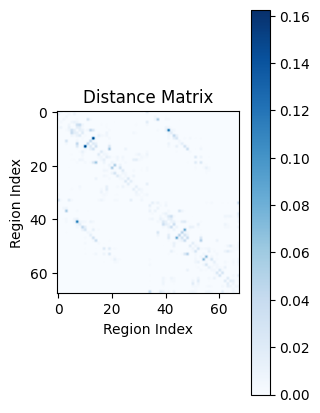

In [17]:
# Get distance matrix, plus sanity checks. The sanity checks show that both distance matrices are only slightly different (e-6). 


# get ORIGINAL distance matrix from consensus 10mb
dist_mat = np.loadtxt(DATA_PATH + "/preprocessed/consensus_10mb/01_weighted_adj_mat_68.csv", delimiter=",")

# plot it 
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(dist_mat, cmap='Blues') 
plt.colorbar()
plt.title("Distance Matrix")
plt.xlabel("Region Index")
plt.ylabel("Region Index")
dist_mat.shape # (68, 68)

# # Sanity check:
# # - it is symmetric
# # - diagonal is 0
# assert np.allclose(dist_mat, dist_mat.T), "Distance matrix is not symmetric!"
# assert np.all(np.diag(dist_mat) == 0), "Diagonal of distance matrix is not zero!"

# # Now, let's make sure the distance matrix is symmetric and has no negative values
# dist_mat = np.array(dist_mat, dtype=float)
# dist_mat_new = (dist_mat + dist_mat.T) / 2
# dist_mat_new[np.diag_indices_from(dist_mat_new)] = 0.0
# tiny = 1e-6
# off = ~np.eye(dist_mat_new.shape[0], dtype=bool)
# dist_mat_new[off] = np.maximum(dist_mat_new[off], tiny)

# # Plotting the difference between the original and new distance matrix
# plt.subplot(1, 3, 2) 
# plt.imshow(dist_mat-dist_mat_new, cmap='Blues')
# plt.colorbar()
# plt.title("Original Distance Matrix minus the new one")
# plt.xlabel("Region Index")
# plt.ylabel("Region Index")  

# # >> MATRICES ARE THE SAME; NO NEED TO REPLACE DISTANCE MATRIX
# # Then, I guess: 
# dist_mat = dist_mat_new.copy()

# plt.subplot(1, 3, 3) 
# plt.imshow(dist_mat, cmap='Blues')
# plt.colorbar()
# plt.title("Updated Distance Matrix")
# plt.xlabel("Region Index")
# plt.ylabel("Region Index")  

In [19]:
# get data from 70 subjects

# Open the MAT-file as an HDF5 container. Loading with "sio.loadmat" does not work here, as the matlab version is too new (v7.3+).
import h5py

with h5py.File(DATA_PATH + "/preprocessed/data_700mb/SC_68.mat", "r") as f:
    all_connectomes = np.array(f["M"])
    print("Data shape:", all_connectomes.shape) # (68, 68, 70) -> 68 regions, 68 regions, 70 subjects

Data shape: (68, 68, 70)


Shape of one connectome: (68, 68)


Text(0, 0.5, 'Region Index')

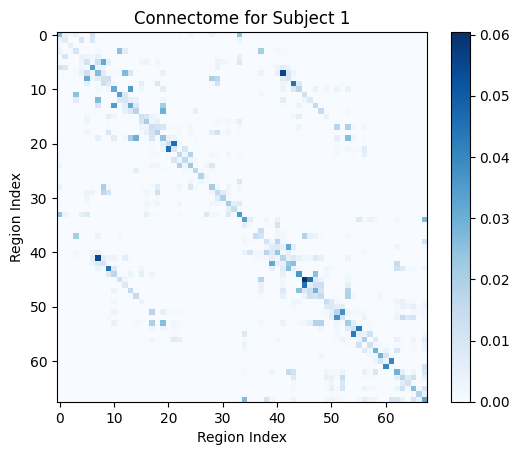

In [20]:
# Get one of the subjects' connectomes, and run "echoes" on it
# https://github.com/fabridamicelli/echoes

one_connectome = all_connectomes[:, :, 0]  # Get the first subject's connectome
print("Shape of one connectome:", one_connectome.shape)  # Should be (68
plt.imshow(one_connectome, cmap='Blues')
plt.colorbar()
plt.title("Connectome for Subject 1")
plt.xlabel("Region Index")
plt.ylabel("Region Index")


In [22]:
import numpy as np
import networkx as nx
import pandas as pd
from networkx.algorithms import community as nx_comm
from scipy.linalg import expm

def _avg_offdiag(M):
    n = M.shape[0]
    Md = M.copy()
    np.fill_diagonal(Md, 0.0)
    return Md.sum() / (n*(n-1))


def _largest_component_char_path_length(G):
    """Characteristic path length on the largest connected component (NaN if <2 nodes)."""
    if G.number_of_nodes() == 0:
        return np.nan
    # Pick largest connected component
    components = list(nx.connected_components(G))
    if not components:
        return np.nan
    H = G.subgraph(max(components, key=len)).copy()
    if H.number_of_nodes() < 2:
        return np.nan
    return nx.average_shortest_path_length(H)

def _get_rich_nodes(G, rich_nodes=None, top_percent=0.20):
    """
    Return a set of 'rich' nodes.
    - If rich_nodes provided (iterable of node indices), use that.
    - Else pick top `top_percent` by degree (ties broken arbitrarily).
    """
    if rich_nodes is not None:
        return set(rich_nodes)
    # default: top X% by degree
    deg = dict(G.degree())
    if len(deg) == 0:
        return set()
    k = max(1, int(np.ceil(top_percent * len(deg))))
    # sort nodes by degree descending and take top k
    sorted_nodes = sorted(deg.items(), key=lambda kv: kv[1], reverse=True)
    return set(n for n, _ in sorted_nodes[:k])

def _communicability(A_bin, mode="estrada_scaled", beta=None, t=1.0):
    """
    Compute average off-diagonal communicability in three modes:
      - estrada:        average of expm(A)
      - estrada_scaled: average of expm(b * A) with b = 1/max(1, λ_max)
      - heat:           average of exp(-t * L_norm) (heat kernel)
    Uses eigen-decomposition for the ‘estrada*’ modes to avoid expm overflows.
    """
    n = A_bin.shape[0]
    # Helper to average off-diagonal entries
    def avg_offdiag(M):
        np.fill_diagonal(M, 0.0)
        return M.sum() / (n*(n-1))

    if mode in ("estrada", "estrada_scaled"):
        # Compute symmetric A
        A = (A_bin + A_bin.T) / 2.0
        # Eigen-decompose once
        eigvals, eigvecs = np.linalg.eigh(A)
        # Determine scaling β
        if mode == "estrada":
            b = 1.0
        else:
            lam_max = np.max(eigvals)
            b = 1.0 / max(1.0, lam_max) if beta is None else beta
        # Exponentiate eigenvalues
        exp_eigs = np.exp(b * eigvals)
        # Reconstruct exp(b A) = V diag(exp(bλ)) V^T
        C = (eigvecs * exp_eigs) @ eigvecs.T
        return avg_offdiag(C)

    elif mode == "heat":
        # Normalized Laplacian L = I - D^{-1/2} A D^{-1/2}
        deg = A_bin.sum(axis=1)
        inv_sqrt = 1.0 / np.sqrt(np.maximum(deg, 1e-12))
        S = np.diag(inv_sqrt)
        L = np.eye(n) - S @ A_bin @ S
        # You can safely call expm here because L's spectrum lies in [0,2]
        from scipy.linalg import expm
        C = expm(-t * L)
        return avg_offdiag(C)

    else:
        raise ValueError("mode must be 'estrada', 'estrada_scaled', or 'heat'.")



def analyze_connectomes(connectomes, distance_matrix,
                        comm_mode="estrada_scaled", beta=None, t=1.0, 
                        rich_nodes_global=None, rich_top_percent=0.20):
    """
    connectomes: either list of (n,n) arrays OR array of shape (k,n,n) or (n,n,k)
    distance_matrix: (n,n) Euclidean distances
    comm_mode: 'estrada' | 'estrada_scaled' | 'heat'
    rich_nodes_global: optional iterable of node indices (same for all nets).
                       If None, uses top `rich_top_percent` by degree per-network.
    rich_top_percent: fraction used when rich_nodes_global is None.
    """
    # Normalize input shape to (k, n, n)
    arr = np.asarray(connectomes)
    if arr.ndim == 2:              # single connectome
        arr = arr[None, ...]       # (1, n, n)
    elif arr.ndim == 3:
        # if (n,n,k), move axes to (k,n,n)
        if arr.shape[0] == arr.shape[1]:
            arr = np.transpose(arr, (2, 0, 1))
        # else assume already (k,n,n)
    else:
        raise ValueError("connectomes must be (n,n), (k,n,n), or (n,n,k).")

    k, n, _ = arr.shape
    if distance_matrix.shape != (n, n):
        raise ValueError(f"distance_matrix must be {(n,n)}, got {distance_matrix.shape}")

    out = []
    for idx in range(k):
        A = np.array(arr[idx], dtype=float)
        # Ensure symmetry & zero diagonal
        A = np.maximum(A, A.T)
        np.fill_diagonal(A, 0.0)

        # Binary graph for global metrics
        A_bin = (A != 0).astype(float)
        G = nx.from_numpy_array(A_bin)

        # 1) Communicability (chosen mode)
        avg_comm = _communicability(A_bin, mode=comm_mode, beta=beta, t=t)

        # 2) Global efficiency
        glob_eff = nx.global_efficiency(G)

        # 3) Modularity (greedy)
        comms = list(nx_comm.greedy_modularity_communities(G))
        modu = nx_comm.modularity(G, comms) if len(comms) > 1 else 0.0 # is if statement ok? 

        # 4) Other global properties
        avg_clust = nx.average_clustering(G) if G.number_of_nodes() > 0 else np.nan # is if statment ok?
        avg_deg = float(np.mean([d for _, d in G.degree()])) if G.number_of_nodes() > 0 else np.nan # is if statment ok?
        trans = nx.transitivity(G) if G.number_of_nodes() > 0 else np.nan # is if statment ok?

        # 5) Average edge distance
        edge_d = [distance_matrix[i, j] for i, j in G.edges()]
        avg_dist = float(np.mean(edge_d)) if edge_d else np.nan

        # 6) Characteristic path length (largest CC)
        cpl = _largest_component_char_path_length(G)

        # 7) Rich-club measures
        rich_nodes = _get_rich_nodes(G, rich_nodes_global, top_percent=rich_top_percent)
        rich_edges = [(u, v) for (u, v) in G.edges() if u in rich_nodes and v in rich_nodes]
        n_rich_edges = len(rich_edges)
        rc_lengths = [distance_matrix[u, v] for (u, v) in rich_edges]
        avg_rc_length = float(np.mean(rc_lengths)) if rc_lengths else np.nan

        out.append({
            "network_index": idx,
            "avg_communicability": avg_comm,
            "global_efficiency": glob_eff,
            "modularity": modu,
            "avg_clustering": avg_clust,
            "avg_degree": avg_deg,
            "transitivity": trans,
            "avg_edge_distance": avg_dist,
            "char_path_length": cpl,
            "richclub_n_edges": n_rich_edges,
            "richclub_avg_length": avg_rc_length,
        })

    return pd.DataFrame(out)

# Calculate graph measures for all connectomes
graph_measures_df = analyze_connectomes(all_connectomes, dist_mat, comm_mode="estrada_scaled")  # This one is more numerically stable (at least for smaller connectomes), as it produces less extreme values.
# df = analyze_connectomes(all_connectomes, dist_mat, comm_mode="estrada") # This one is less stable, but follows BCT's communicability_bin behavior more closely.
pd.DataFrame.to_csv(graph_measures_df, OUTPUT_PATH + "/graph_measures_df.csv")
graph_measures_df

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_14174/4119552479.py:72: RuntimeWarning: divide by zero encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_14174/4119552479.py:72: RuntimeWarning: overflow encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_14174/4119552479.py:72: RuntimeWarning: invalid value encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T


,network_index,avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree,transitivity,avg_edge_distance,char_path_length,richclub_n_edges,richclub_avg_length
0,0,0.021013,0.597198,0.307704,0.610804,16.470588,0.513818,0.005878,1.911326,56,0.007240
1,1,0.021570,0.637913,0.215782,0.601557,19.529412,0.508043,0.004954,1.755487,62,0.006178
2,2,0.020930,0.607002,0.341498,0.628308,17.205882,0.519266,0.005537,1.872256,70,0.004997
3,3,0.020660,0.635426,0.285663,0.650042,20.029412,0.545131,0.004863,1.785338,76,0.004916
4,4,0.021431,0.621086,0.293950,0.603201,18.588235,0.530460,0.005208,1.828358,68,0.004923
...,...,...,...,...,...,...,...,...,...,...,...
65,65,0.021095,0.621634,0.281932,0.601182,18.352941,0.507955,0.005279,1.818262,65,0.005305
66,66,0.020561,0.597381,0.341336,0.614537,16.500000,0.514720,0.005830,1.909131,63,0.005171
67,67,0.021183,0.613367,0.304807,0.607088,17.647059,0.514428,0.005425,1.846795,61,0.004781
68,68,0.021954,0.643986,0.245783,0.601241,20.441176,0.511276,0.004770,1.746708,63,0.005449


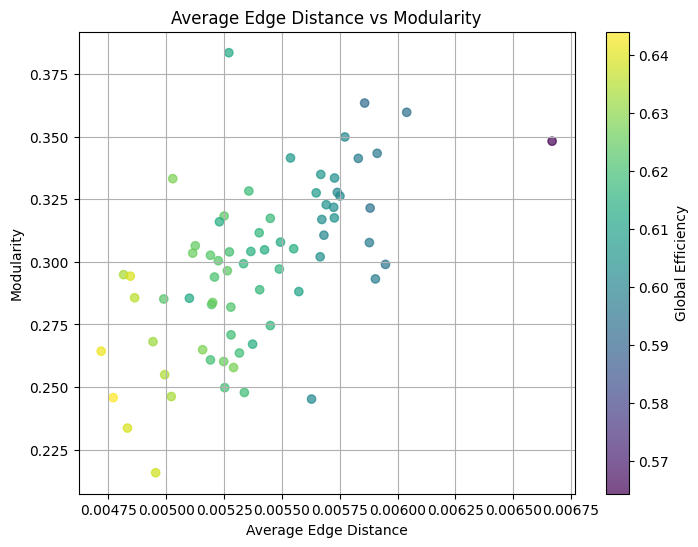

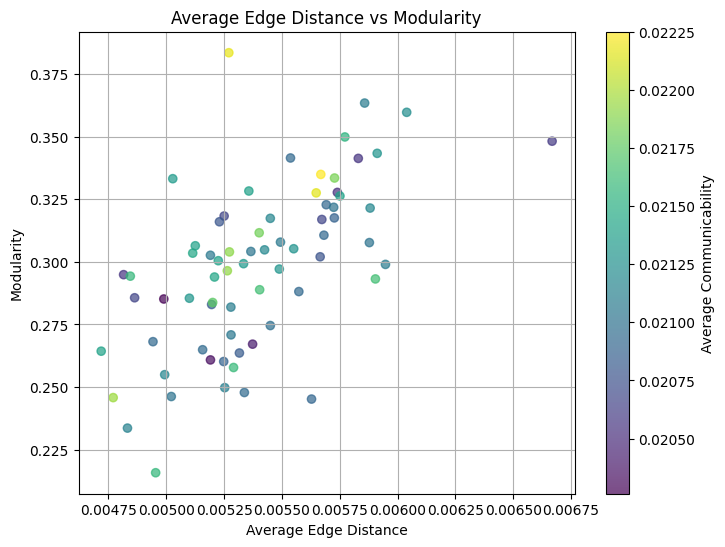

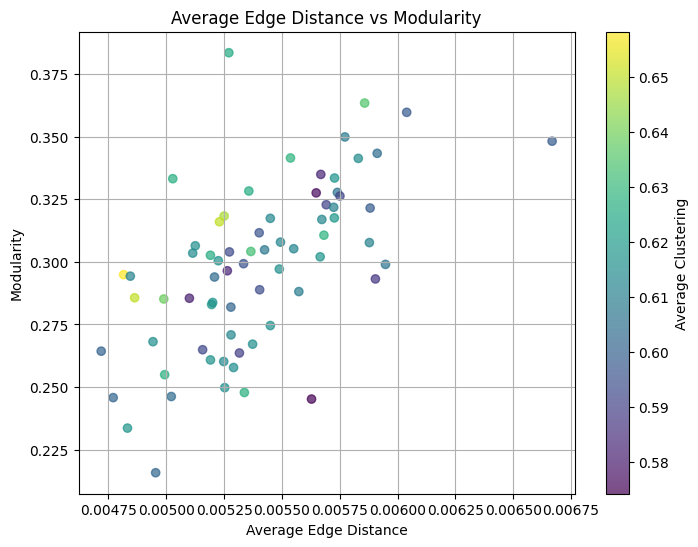

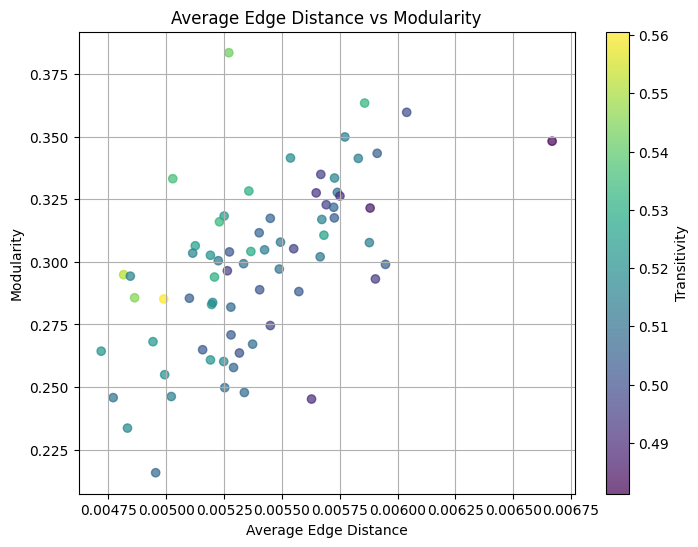

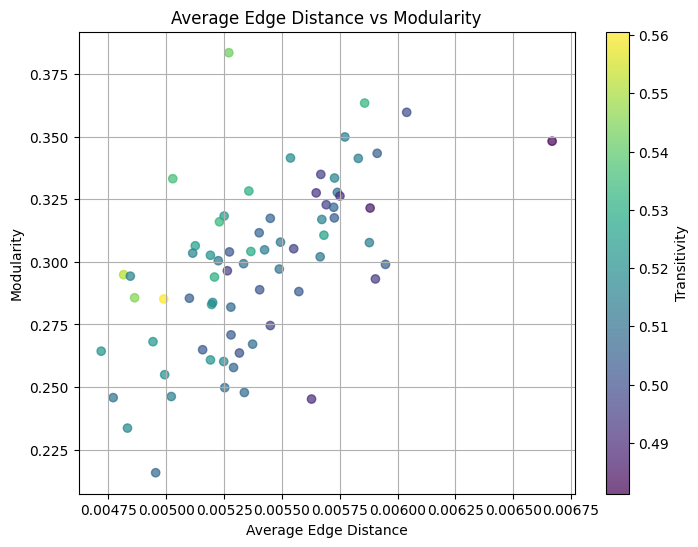

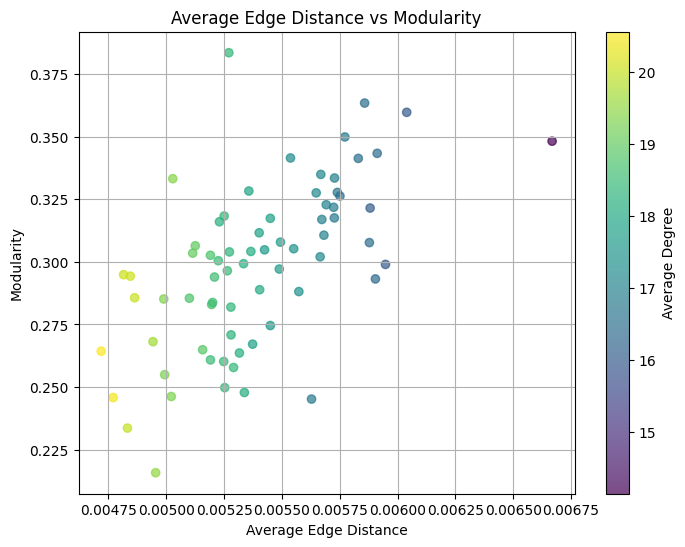

In [52]:
# 2D scatterplots

df = graph_measures_df
# plt.figure(figsize=(6, 6))
# plt.scatter(df['avg_communicability'], df['global_efficiency'], alpha=0.7)
# plt.title('Average Communicability vs Global Efficiency')
# plt.xlabel('Average Communicability')
# plt.ylabel('Global Efficiency')
# plt.grid(True)
# plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['global_efficiency'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Global Efficiency')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['avg_communicability'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Average Communicability')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['avg_clustering'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Average Clustering')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['transitivity'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Transitivity')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['transitivity'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Transitivity')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['avg_degree'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Average Degree')
plt.grid(True)
plt.show()

# plt.figure(figsize=(6, 6))
# # sort by avg_communicability
# plt.plot(df['avg_communicability'], alpha=0.7)
# plt.title('Average Communicability vs Global Efficiency')
# plt.xlabel('Average Communicability')
# plt.ylabel('Global Efficiency')
# plt.grid(True)
# plt.show()


# "network_index": idx,
#             "avg_communicability": avg_comm,
#             "global_efficiency": glob_eff,
#             "modularity": modu,
#             "avg_clustering": avg_clust,
#             "avg_degree": avg_deg,
#             "transitivity": trans,
#             "avg_edge_distance": avg_dist

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import ks_2samp
from numpy.random import default_rng

# ----------  Energy calculation (Mousley et al.)  ---------- #

def gnm_energy(A_obs, A_sim, dist_mat):
    """
    Compute energy = max(KS_degree, KS_clustering, KS_betweenness, KS_edge_length).
    A_obs and A_sim must be binary and undirected.
    """
    def prep(A):
        A_bin = (A > 0).astype(int)
        A_bin = np.triu(A_bin, k=1)
        return A_bin + A_bin.T

    # binarize, ensure symmetry & zero diagonal
    B_obs = prep(A_obs)
    B_sim = prep(A_sim)

    G_obs = nx.from_numpy_array(B_obs)
    G_sim = nx.from_numpy_array(B_sim)

    # Degree
    deg_obs = np.array([d for _, d in G_obs.degree()])
    deg_sim = np.array([d for _, d in G_sim.degree()])
    ks_degree = ks_2samp(deg_obs, deg_sim).statistic

    # Clustering coefficient
    cc_obs = np.array(list(nx.clustering(G_obs).values()))
    cc_sim = np.array(list(nx.clustering(G_sim).values()))
    ks_cc = ks_2samp(cc_obs, cc_sim).statistic

    # Betweenness centrality
    bc_obs = np.array(list(nx.betweenness_centrality(G_obs, normalized=True).values()))
    bc_sim = np.array(list(nx.betweenness_centrality(G_sim, normalized=True).values()))
    ks_bc = ks_2samp(bc_obs, bc_sim).statistic

    # Edge length distributions (using Euclidean distance matrix)
    def edge_lengths(G):
        return np.array([dist_mat[i, j] for i, j in G.edges()])
    el_obs = edge_lengths(G_obs)
    el_sim = edge_lengths(G_sim)
    ks_el = ks_2samp(el_obs, el_sim).statistic

    energy = max(ks_degree, ks_cc, ks_bc, ks_el)
    return energy


# ----------  GNM simulation  ---------- #

def compute_homophily_matrix(A):
    A = (A > 0).astype(int)
    shared = A @ A
    deg = A.sum(axis=1)
    denom = deg[:, None] + deg[None, :] - shared
    with np.errstate(divide='ignore', invalid='ignore'):
        k = np.where(denom > 0, shared / denom, 0.0)
    np.fill_diagonal(k, 0.0)
    return k

def generate_gnm(A_seed, target_m, dist_mat, gamma, eta, rng=None, eps=1e-12):
    """
    Grow until A has target_m undirected edges.
    P(i,j) ∝ (d_ij)**eta * (k_ij)**gamma, with eps-stabilization.
    """
    rng = np.random.default_rng() if rng is None else rng
    A = A_seed.copy().astype(float)
    n = A.shape[0]

    # Distance term: guard against zeros & negatives
    D = np.array(dist_mat, dtype=float)
    D = np.maximum(D, eps)         # avoid 0**negative
    np.fill_diagonal(D, np.inf)    # never consider self-edges
    with np.errstate(over='ignore'):
        cost_term = D ** eta       # finite because D>=eps

    while (A.sum() // 2) < target_m:
        # Recompute homophily each step
        k_mat = compute_homophily_matrix((A > 0).astype(int))
        k_safe = np.maximum(k_mat, eps)  # avoid 0**negative
        with np.errstate(over='ignore'):
            value_term = k_safe ** gamma

        # Candidate edges: only absent upper-triangular
        mask = np.triu((A == 0), k=1)
        prob = cost_term * value_term
        prob = prob * mask

        # Remove non-finite junk
        prob[~np.isfinite(prob)] = 0.0
        total = prob.sum()

        if total <= 0:
            # uniform fallback among missing edges
            cand = np.argwhere(mask)
            i, j = cand[rng.integers(0, len(cand))]
        else:
            cand = np.argwhere(mask)
            p_flat = prob[mask].ravel()
            p_flat = p_flat / p_flat.sum()  # renormalize
            i, j = cand[rng.choice(len(cand), p=p_flat)]

        A[i, j] = 1.0
        A[j, i] = 1.0

    return A


# ----------  Binarization for edges  ---------- # Needed for GNM fitting
def _binarize_for_edges(A, thr=0.0):
    A = np.asarray(A, float)
    A = (A + A.T) / 2.0
    np.fill_diagonal(A, 0.0)
    A_bin = (A > thr).astype(int)   # set your threshold here
    return A_bin

# ----------  Grid search + evaluation per subject  ---------- #

def fit_gnm_for_subject(A_obs, dist_mat, wide_eta=(-8, 0), wide_gamma=(-8, 8),
                        wide_grid=25, narrow_eta=(-3, 0), narrow_gamma=(0.1, 0.6),
                        narrow_grid=25, sample_probability=0.1, rng=None):
    """
    For one subject, perform a wide and narrow grid search to find the best (eta, gamma),
    optionally sampling some generated networks to run ESN analysis immediately.
    
    Returns:
      best_params: dict with gamma, eta, energy.
      sampled_models: list of (A_sim, eta, gamma) randomly chosen according to sample_probability.
      energy_grid: DataFrame with columns ['eta', 'gamma', 'energy'] from the narrow search.
    """
    rng = default_rng() if rng is None else rng

    n = A_obs.shape[0]
    # m_edges = int(A_obs.sum() // 2)
    
    A_bin = _binarize_for_edges(A_obs, thr=0.0)  # or pick a real threshold
    m_edges = int(np.triu(A_bin, k=1).sum())

    # Prepare seed network: 10% density network as in Mousley et al. (or use your own)
    # Here we use the union of edges present in >95% of all subjects; you can compute
    # this prior to looping over subjects. For simplicity we start with an empty seed.
    A_seed = np.zeros_like(A_obs)

    # Wide grid to estimate good region (coarse)
    wide_eta_values = np.linspace(wide_eta[0], wide_eta[1], wide_grid)
    wide_gamma_values = np.linspace(wide_gamma[0], wide_gamma[1], wide_grid)
    energies_wide = []
    for eta in wide_eta_values:
        for gamma in wide_gamma_values:
            A_sim = generate_gnm(A_seed, m_edges, dist_mat, gamma, eta, rng)
            energy = gnm_energy(A_obs, A_sim, dist_mat)
            energies_wide.append((eta, gamma, energy))
    # Identify roughly best region
    energies_wide = np.array(energies_wide, dtype=[('eta', float), ('gamma', float), ('energy', float)])
    best_eta_approx, best_gamma_approx = energies_wide['eta'][energies_wide['energy'].argmin()], \
                                         energies_wide['gamma'][energies_wide['energy'].argmin()]

    # Narrow grid around Mousley’s recommended range
    narrow_eta_values = np.linspace(narrow_eta[0], narrow_eta[1], narrow_grid)
    narrow_gamma_values = np.linspace(narrow_gamma[0], narrow_gamma[1], narrow_grid)
    energy_grid = []
    sampled_models = []
    best_energy = np.inf
    best_eta, best_gamma = None, None

    for eta in narrow_eta_values:
        for gamma in narrow_gamma_values:
            A_sim = generate_gnm(A_seed, m_edges, dist_mat, gamma, eta, rng)
            energy = gnm_energy(A_obs, A_sim, dist_mat)
            energy_grid.append({"eta": eta, "gamma": gamma, "energy": energy})
            # Keep track of best
            if energy < best_energy:
                best_energy = energy
                best_eta, best_gamma = eta, gamma
            # With some probability, save this network for later ESN analysis
            if rng.random() < sample_probability:
                sampled_models.append((A_sim.copy(), eta, gamma))

    energy_df = pd.DataFrame(energy_grid)
    best_params = {"eta": best_eta, "gamma": best_gamma, "energy": best_energy}
    return best_params, sampled_models, energy_df



# ----------  Full pipeline across subjects  ---------- #

def run_full_gnm_and_esn_pipeline(connectomes, dist_mat, sample_prob=0.1,
                                  n_sample_limit=100):
    """
    Run GNM fitting and ESN analysis. Performs grid search for each subject,
    collects best parameters and energy, then runs ESN analysis on a random
    subset of generated networks. Returns DataFrames with results.
    sample_prob controls how often to keep a generated GNM for ESN testing.
    """
    rng = default_rng(0)

    n_subj = connectomes.shape[2]
    best_param_rows = []
    energy_details = []
    sampled_networks = []

    # 1) Fit GNMs for all subjects and collect random samples
    for subj in range(n_subj):
        A_obs = connectomes[:, :, subj].copy()
        if A_obs.shape[0] != A_obs.shape[1]:
            raise ValueError(f"Connectome for subject {subj} is not square: {A_obs.shape}")
        best_params, samples, energy_grid = fit_gnm_for_subject(
            A_obs, dist_mat, wide_grid=3, narrow_grid=3, sample_probability=sample_prob, rng=rng) # wide_grid=10, narrow_eta=(-3, 0), narrow_gamma=(0.1, 0.6), narrow_grid=10, sample_probability=0.1, rng=None)
        
        best_param_rows.append({"network_index": subj,
                                "gamma": best_params["gamma"],
                                "eta": best_params["eta"],
                                "energy": best_params["energy"]})
        energy_grid["network_index"] = subj
        energy_details.append(energy_grid)
        # Add samples to global list
        for A_sim, eta, gamma in samples:
            sampled_networks.append({"A_sim": A_sim, "eta": eta, "gamma": gamma, "subject": subj})
        print(f"[Subj {subj}] best eta={best_params['eta']:.3f}, gamma={best_params['gamma']:.3f}, energy={best_params['energy']:.3f}")

    # Create DataFrames
    df_best = pd.DataFrame(best_param_rows)
    df_energy_details = pd.concat(energy_details, ignore_index=True)

    # 2) Sample networks for ESN analysis (limit total to n_sample_limit)
    rng.shuffle(sampled_networks)
    sampled_networks = sampled_networks[:n_sample_limit]
    esn_records = []

    for i, item in enumerate(sampled_networks):
        A_sim = item["A_sim"]
        subj_idx = item["subject"]
        eta = item["eta"]
        gamma = item["gamma"]
        # Build reservoir, evaluate memory capacity and sequence recall using your functions
        W = build_reservoir_from_connectome(A_sim, spectral_radius=0.99, rank=False)
        mc = evaluate_memory_capacity(W, n_lags=50, train_len=4000, test_len=1000,
                                      n_runs=10, random_state=i)
        seq = evaluate_sequence_recall(W, pattern_lengths=range(5, 26),
                                       train_trials=800, test_trials=200,
                                       n_runs=5, random_state=i)
        esn_records.append({
            "sample_index": i,
            "subject": subj_idx,
            "eta": eta,
            "gamma": gamma,
            "memory_capacity": mc,
            "sequence_recall": seq
        })
        # print(f"ESN sample {i}: subj={subj_idx}, eta={eta:.3f}, gamma={gamma:.3f}, MC={mc:.3f}, SR={seq:.3f}")

    df_esn = pd.DataFrame(esn_records)

    return df_best, df_energy_details, df_esn

# Example usage:
# connectomes: np.array shape (68, 68, 70)
# dist_mat: your (68,68) distance matrix
# df_best, df_energy_grids, df_esn = run_full_gnm_and_esn_pipeline(all_connectomes, dist_mat)

# Different numbers of connectomes: 
# less_connectomes = np.array([all_connectomes[:,:,0]]).T
less_connectomes = all_connectomes[:, :, :5]  # Use first 5 connectomes for testing
df_best, df_energy_grids, df_esn = run_full_gnm_and_esn_pipeline(less_connectomes, dist_mat)
# df_best.to_csv("gnm_best_params.csv", index=False)
# df_esn.to_csv("gnm_esn_results.csv", index=False)

# 5 in 1 minute. 

NameError: name 'all_connectomes' is not defined

In [48]:
df_best.to_csv(OUTPUT_PATH + "/gnm_best_params.csv", index=False)
df_best

,network_index,gamma,eta,energy
0,0,0.60,0.0,0.632353
1,1,0.35,0.0,0.540663
2,2,0.35,0.0,0.750000
3,3,0.35,0.0,0.750000
4,4,0.35,0.0,0.808824


In [49]:
df_energy_grids.to_csv(OUTPUT_PATH + "/gnm_energy_grids.csv", index=False)
df_energy_grids

,eta,gamma,energy,network_index
0,-3.0,0.10,0.883929,0
1,-3.0,0.35,0.883929,0
2,-3.0,0.60,0.883929,0
3,-1.5,0.10,0.883929,0
4,-1.5,0.35,0.883929,0
5,-1.5,0.60,0.883929,0
6,0.0,0.10,0.867647,0
7,0.0,0.35,0.911765,0
8,0.0,0.60,0.632353,0
9,-3.0,0.10,0.808824,1


In [50]:
df_esn.to_csv(OUTPUT_PATH + "/gnm_esn_results.csv", index=False)
df_esn 

,sample_index,subject,eta,gamma,memory_capacity,sequence_recall
0,0,3,-1.5,0.10,"{'mc_mean': 1.047211264168265, 'mc_std': 0.012...","{5: {'r2_mean': 0.8473831328795267, 'r2_std': ..."
1,1,3,0.0,0.35,"{'mc_mean': 1.0470825477075856, 'mc_std': 0.01...","{5: {'r2_mean': 0.807511612702023, 'r2_std': 0..."
2,2,4,0.0,0.10,"{'mc_mean': 1.0476699340902944, 'mc_std': 0.01...","{5: {'r2_mean': 0.9089247307841241, 'r2_std': ..."
3,3,0,-3.0,0.60,"{'mc_mean': 1.0483095154848576, 'mc_std': 0.00...","{5: {'r2_mean': 0.7912262804285591, 'r2_std': ..."


In [55]:

# Plotting 

import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

def compute_energy_landscape(connectomes, dist_mat,
                             eta_range=(-3.0, 0.0), gamma_range=(0.1, 0.6),
                             grid_size=(100, 100), seed=0):
    """
    Compute a group energy landscape over an (eta, gamma) grid.
    For each grid cell we simulate ONE network for each subject and take the
    median energy across subjects (fast + smooth enough). Increase reps if needed.

    Returns
    -------
    etas, gammas : 1D arrays
    energy_grid  : (len(gammas), len(etas)) median energy across subjects
    """
    rng = default_rng(seed)
    n = connectomes.shape[0]
    m_subj = connectomes.shape[2]

    etas   = np.linspace(eta_range[0], eta_range[1], grid_size[0])
    gammas = np.linspace(gamma_range[0], gamma_range[1], grid_size[1])

    # target number of undirected edges per subject (match observed density)
    # target_m = [int(connectomes[:, :, s].sum() // 2) for s in range(m_subj)]
    target_m = []
    for s in range(m_subj):
        A_bin = _binarize_for_edges(connectomes[:, :, s], thr=0.0)  # or pick a real threshold
        m_edges = int(np.triu(A_bin, k=1).sum())
        target_m.append(m_edges)

    print(f"Target edges per subject: {target_m}")

    # start from empty seed (you can replace with a consensus 10% seed if you have it)
    A_seed = np.zeros((n, n), dtype=float)

    energy_grid = np.zeros((len(gammas), len(etas)), dtype=float)

    for gi, gamma in enumerate(gammas):
        for ei, eta in enumerate(etas):
            energies = []
            for s in range(m_subj):
                A_sim = generate_gnm(A_seed, target_m[s], dist_mat, gamma, eta, rng)
                E = gnm_energy(connectomes[:, :, s], A_sim, dist_mat)
                energies.append(E)
                print(f"Subject {s}, eta={eta:.3f}, gamma={gamma:.3f}, energy={E:.3f}")
            # Use median for robustness to stochasticity
            energy_grid[gi, ei] = float(np.median(energies))
    return etas, gammas, energy_grid


def plot_energy_landscape(etas, gammas, energy_grid, df_best=None,
                          title="", # 10,000 simulations",
                          vmin=None, vmax=None, savepath=None, show=True):
    """
    Plot a Figure-4-style heatmap with optional white dots for best-fit models.
    """
    fig, ax = plt.subplots(figsize=(6.2, 5.2)) # , dpi=150)

    # Heatmap: black=low (good), yellow=high (bad) like Mousley; 'hot' does that.
    im = ax.imshow(energy_grid,
                   origin="lower",
                   extent=[etas.min(), etas.max(), gammas.min(), gammas.max()],
                   aspect="auto",
                   cmap="hot",
                   vmin=vmin, vmax=vmax,
                   interpolation="bilinear")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Energy", rotation=270, labelpad=12)

    # Axis labels/range
    ax.set_xlabel("η")
    ax.set_ylabel("γ")
    ax.set_title(title)

    # Overlay best-fit points (one per subject)
    if df_best is not None and {"eta","gamma"}.issubset(df_best.columns):
        ax.scatter(df_best["eta"].values, df_best["gamma"].values,
                #    s=8, c="white", edgecolors="none", alpha=0.95, zorder=3)
                   s=16, c="blue", edgecolors="none", alpha=0.95, zorder=3)
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()
    return fig, ax


In [ ]:
# Create figure 4 from Alexas paper
# 100 x 100 grid = ~10k sims  ➜ similar to the paper’s narrow sweep
number_individual_gammas = 50
number_individual_etas = 50
etas, gammas, E = compute_energy_landscape(all_connectomes, dist_mat,
                                        eta_range=(-8, 0), gamma_range=(-8, 8),
                                        # grid_size=(100, 100), seed=42) 
                                        grid_size=(number_individual_etas, number_individual_gammas), seed=42) # etas first, then gammas

print(etas.shape, gammas.shape, E.shape)

# 7.516666666666667 h (i.e 451 minutes) for 50x50 grid 

Target edges per subject: [560, 664, 585, 681, 632, 656, 543, 607, 638, 570, 646, 625, 628, 657, 579, 655, 602, 682, 637, 544, 584, 559, 630, 577, 481, 609, 571, 625, 680, 567, 561, 659, 699, 616, 606, 621, 647, 570, 607, 619, 582, 618, 562, 576, 546, 556, 619, 613, 626, 632, 573, 597, 601, 578, 628, 642, 623, 594, 629, 584, 669, 615, 637, 682, 627, 624, 561, 600, 695, 592]
Subject 0, eta=-8.000, gamma=-8.000, energy=1.000
Subject 1, eta=-8.000, gamma=-8.000, energy=1.000
Subject 2, eta=-8.000, gamma=-8.000, energy=1.000
Subject 3, eta=-8.000, gamma=-8.000, energy=1.000
Subject 4, eta=-8.000, gamma=-8.000, energy=1.000
Subject 5, eta=-8.000, gamma=-8.000, energy=1.000
Subject 6, eta=-8.000, gamma=-8.000, energy=1.000
Subject 7, eta=-8.000, gamma=-8.000, energy=1.000
Subject 8, eta=-8.000, gamma=-8.000, energy=0.985
Subject 9, eta=-8.000, gamma=-8.000, energy=1.000
Subject 10, eta=-8.000, gamma=-8.000, energy=1.000
Subject 11, eta=-8.000, gamma=-8.000, energy=1.000
Subject 12, eta=-8.00

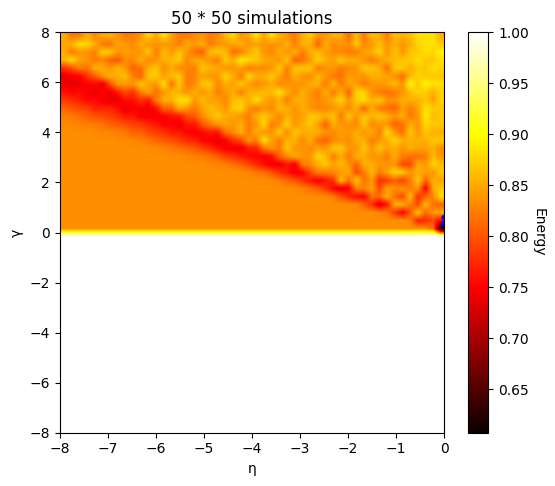

,network_index,gamma,eta,energy
0,0,0.60,0.0,0.632353
1,1,0.35,0.0,0.540663
2,2,0.35,0.0,0.750000
3,3,0.35,0.0,0.750000
4,4,0.35,0.0,0.808824


In [57]:
#  Plot + overlay the white dots = each subject’s best-fit (eta, gamma)

title_part = f"{number_individual_gammas}_{number_individual_etas}"
plot_energy_landscape(etas, gammas, E, df_best=df_best,
                    title=f"{number_individual_etas} * {number_individual_gammas} simulations", savepath=OUTPUT_PATH + f"/figure4_like_heatmap_{title_part}.png")

# save the energy landscape data
energy_landscape_df = pd.DataFrame(E, columns=etas, index=gammas)
energy_landscape_df.index.name = 'gamma'
energy_landscape_df.columns.name = 'eta'
energy_landscape_df.to_csv(OUTPUT_PATH + f"energy_landscape_{title_part}.csv")

df_best

In [58]:
print("Finished")

Finished


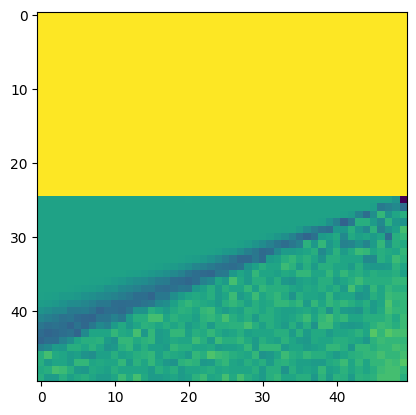

In [61]:
plt.imshow(E)

In [71]:
E[gammas < 0].shape

(25, 50)

In [69]:
gammas[gammas < 0]

array([-8.        , -7.67346939, -7.34693878, -7.02040816, -6.69387755,
       -6.36734694, -6.04081633, -5.71428571, -5.3877551 , -5.06122449,
       -4.73469388, -4.40816327, -4.08163265, -3.75510204, -3.42857143,
       -3.10204082, -2.7755102 , -2.44897959, -2.12244898, -1.79591837,
       -1.46938776, -1.14285714, -0.81632653, -0.48979592, -0.16326531])

(50, 50) (50,) (50,)
-8.0 0.0 -8.0 8.0


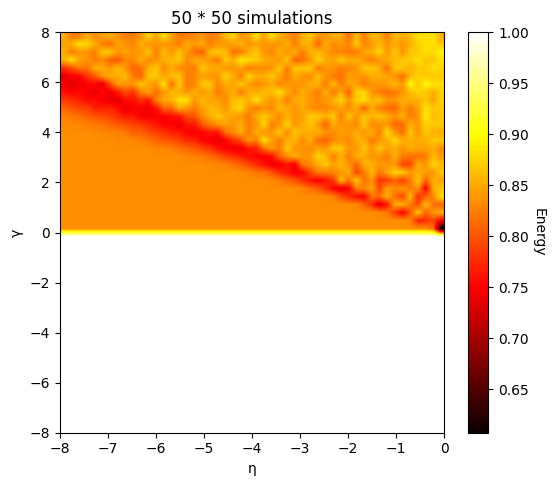

(<Figure size 620x520 with 2 Axes>,
 <Axes: title={'center': '50 * 50 simulations'}, xlabel='η', ylabel='γ'>)

In [84]:
def plot_energy_landscape_small(etas, gammas, energy_grid, df_best=None,
                          title="", # 10,000 simulations",
                          vmin=None, vmax=None, savepath=None, show=True):
    """
    Plot a Figure-4-style heatmap with optional white dots for best-fit models.
    """
    fig, ax = plt.subplots(figsize=(6.2, 5.2)) # , dpi=150)

    gammas_short = gammas #[gammas < 0]
    E_short = energy_grid #[gammas < 0] 
    print(E_short.shape, gammas_short.shape, etas.shape)
    print(etas.min(), etas.max(), gammas_short.min(), gammas_short.max())
    
    # Heatmap: black=low (good), yellow=high (bad) like Mousley; 'hot' does that.
    im = ax.imshow(E_short,
                   origin="lower",
                   extent=[etas.min(), etas.max(), gammas_short.min(), gammas_short.max()],
                   aspect="auto",
                   cmap="hot",
                   vmin=vmin, vmax=vmax,
                   interpolation="bilinear")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Energy", rotation=270, labelpad=12)

    # Axis labels/range
    ax.set_xlabel("η")
    ax.set_ylabel("γ")
    ax.set_title(title)

    # # Overlay best-fit points (one per subject)
    # if df_best is not None and {"eta","gamma"}.issubset(df_best.columns):
    #     ax.scatter(df_best["eta"].values, df_best["gamma"].values,
    #             #    s=8, c="white", edgecolors="none", alpha=0.95, zorder=3)
    #                s=16, c="blue", edgecolors="none", alpha=0.95, zorder=3)
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()
    return fig, ax

title_part = f"{number_individual_gammas}_{number_individual_etas}"
plot_energy_landscape_small(etas, gammas, E, df_best=df_best,
                    title=f"{number_individual_etas} * {number_individual_gammas} simulations")